# Robust Lp: reweight the residuals

How can an objective stop a few large gradient errors from dominating the entire fit?

We start with numbers that can be checked by hand, draw the algorithm’s decision, then run the public API on data with known truth. All phase values are in radians unless stated otherwise.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = Path.cwd().resolve()
if not (ROOT / 'src' / 'parvaneh').is_dir(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
import parvaneh as pv
plt.rcParams.update({'figure.dpi': 115, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
def W(x): return (np.asarray(x)+np.pi) % (2*np.pi)-np.pi
def table(headers, rows):
    display(Markdown('| '+' | '.join(headers)+' |\n|'+
        '|'.join(['---']*len(headers))+'|\n'+
        '\n'.join('| '+' | '.join(map(str,r))+' |' for r in rows)))
def images(arrays, titles, cmap='viridis'):
    fig,axes=plt.subplots(1,len(arrays),figsize=(4*len(arrays),3.4),constrained_layout=True)
    for ax,a,title in zip(np.atleast_1d(axes),arrays,titles):
        im=ax.imshow(a,cmap=cmap); ax.set(title=title,xlabel='column',ylabel='row')
        fig.colorbar(im,ax=ax,shrink=.75)
    plt.show()
def align(u,t): return u-np.mean(u-t)
def scene():
    y,x=np.mgrid[0:18,0:22]
    truth=.38*x+.22*y+1.4*np.exp(-((x-12)**2+(y-8)**2)/25)
    patch=(x>=8)&(x<=14)&(y>=5)&(y<=12)
    rng=np.random.default_rng(21)
    phase=W(truth+rng.normal(size=truth.shape)*np.where(patch,1.35,.06))
    confidence=np.where(patch,.2,1.)
    return truth,phase,confidence
def report(u,t,w):
    assert u.shape==t.shape and np.isfinite(u).all()
    table(['Quantity','Measured value'],[
        ['Aligned RMSE (rad)',f'{pv.rmse_aligned(u,t):.6f}'],
        ['Raw max wrapped difference from input (rad)',f'{np.max(np.abs(W(u-w))):.6f}']])
    images([align(u,t),align(u,t)-t],['Aligned reconstruction (rad)','Error against truth (rad)'])

## 1 · Work through the model

Let $e=Du-g$. Instead of $\sum e^2$, minimize the smoothed objective
$J_p=\sum(e^2+\epsilon^2)^{p/2}$ for $1\le p\le2$.
Differentiating a term gives $p e(e^2+\epsilon^2)^{p/2-1}$.
Freeze the factor $q=(e^2+\epsilon^2)^{p/2-1}$ and solve weighted least squares.

1. Start from ordinary least squares.
2. Compute residuals on horizontal and vertical edges.
3. Update $q$; large residuals receive less relative weight when $p<2$.
4. Solve for a new surface with those edge weights.
5. Stop on relative change or the outer iteration limit.

For $p=1$ and small $\epsilon$, residuals 0.1 and 2 have weights near 10 and 0.5.
This is adaptive residual weighting, not supplied measurement confidence.

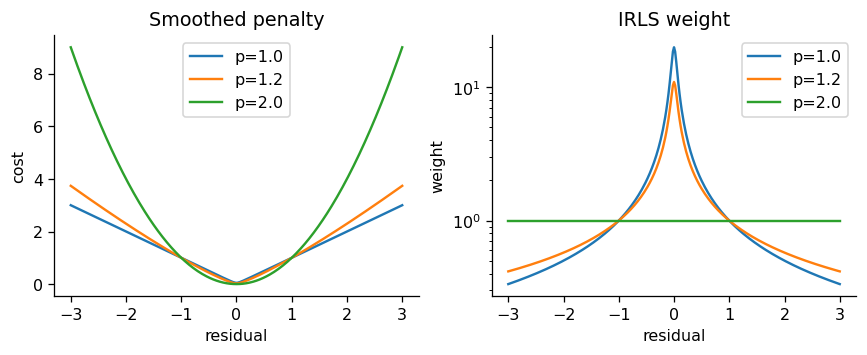

In [2]:
e=np.linspace(-3,3,301); eps=.05
fig,axes=plt.subplots(1,2,figsize=(9,3))
for p in [1.,1.2,2.]:
    axes[0].plot(e,(e*e+eps*eps)**(p/2),label=f'p={p}')
    axes[1].plot(e,(e*e+eps*eps)**(p/2-1),label=f'p={p}')
axes[0].set(title='Smoothed penalty',xlabel='residual',ylabel='cost')
axes[1].set(title='IRLS weight',xlabel='residual',ylabel='weight'); axes[1].set_yscale('log')
for ax in axes: ax.legend()
plt.show()

## 2 · Read the calculation

Reducing $p$ makes a large residual less expensive relative to many smaller
residuals. The algorithm may concentrate disagreement instead of spreading it.
The positive $\epsilon$ prevents an infinite weight at zero residual, but also
changes the objective near zero. A robust fit still need not preserve wrapped values.

## 3 · Run the implementation

The seed and input sizes below are fixed. A low objective or a converged solver means the chosen mathematical problem was solved; it does not prove the physical phase was recovered.

LpInfo(p=1.2, outer_iterations=12, inner_iterations=645, objective=25.02099394902926, relative_change=9.304046425741419e-05)


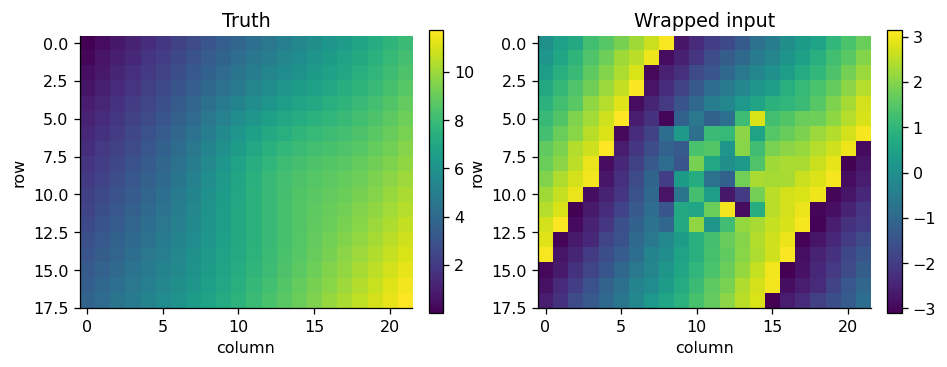

| Quantity | Measured value |
|---|---|
| Aligned RMSE (rad) | 0.402635 |
| Raw max wrapped difference from input (rad) | 2.962432 |

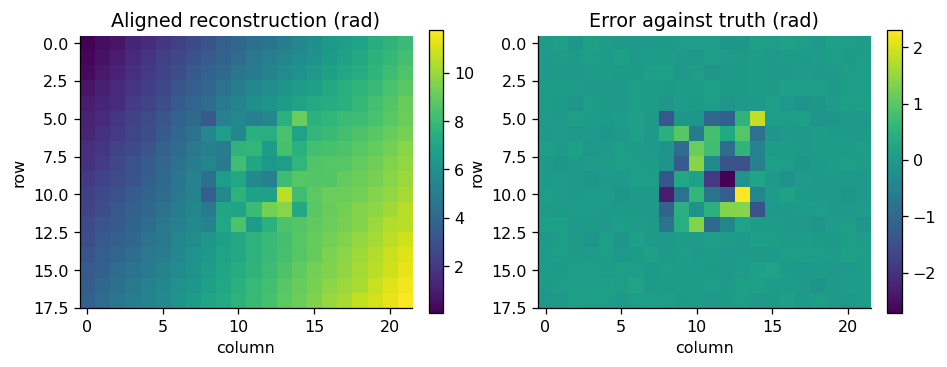

In [3]:
truth,phase,confidence=scene()
u,info=pv.unwrap_lp(phase,p=1.2,outer_iter=12,return_info=True)
print(info); images([truth,phase],['Truth','Wrapped input']); report(u,truth,phase)

## 4 · Change one choice and measure its effect

This controlled experiment changes a solver setting, data condition, or reference calculation. Compare the measured values before drawing a conclusion.

In [4]:
rows=[]
for p in [2.,1.5,1.2,1.]:
    u,info=pv.unwrap_lp(phase,p=p,return_info=True)
    rows.append([p,info.outer_iterations,f'{info.objective:.3f}',f'{pv.rmse_aligned(u,truth):.4f}'])
table(['p','Outer iterations','Own objective','Aligned RMSE'],rows)
assert np.allclose(pv.unwrap_lp(phase,p=2),pv.unwrap(phase))

| p | Outer iterations | Own objective | Aligned RMSE |
|---|---|---|---|
| 2.0 | 0 | 45.812 | 0.4929 |
| 1.5 | 12 | 34.783 | 0.3747 |
| 1.2 | 12 | 25.021 | 0.4026 |
| 1.0 | 12 | 19.595 | 0.4045 |

## 5 · Interpretation and limits

Objective numbers for different $p$ measure different functions and cannot be
ranked as if they were the same score. Compare a shared metric such as aligned
RMSE instead. The current `unwrap_lp` API requires 2-D data and has no external
weight argument. A smaller $p$ is not guaranteed to improve a particular scene.

## Continue exploring

Rerun with another seed or a larger phase step. Predict which assumption fails first, then inspect the result and report. The method’s output convention and masks matter as much as its RMSE.

Implementation: [`minimum_norm.py`](../src/parvaneh/minimum_norm.py). See the [API reference](../docs/api.md), [notebook index](../docs/notebooks.md), [mathematical derivations](../docs/mathematics.md), and [bibliography](../docs/references.md) for further reading. These examples describe the current implementation, including its limitations; they are not claims of numerical identity with external software.